## Handling Missing Values:
* Missing values are handled manually as far as possible.
* Values are also handled by statistical techniques: fillna & dropna

In [2]:
import seaborn as sns

In [4]:
df = sns.load_dataset('titanic') # load the titanic dataset from seaborn library

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.isnull() # returns a bool dataframe where True indicateds a missing value

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [8]:
type(df)

pandas.core.frame.DataFrame

In [11]:
df.isnull().sum() # returns number of missing value

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


<Axes: >

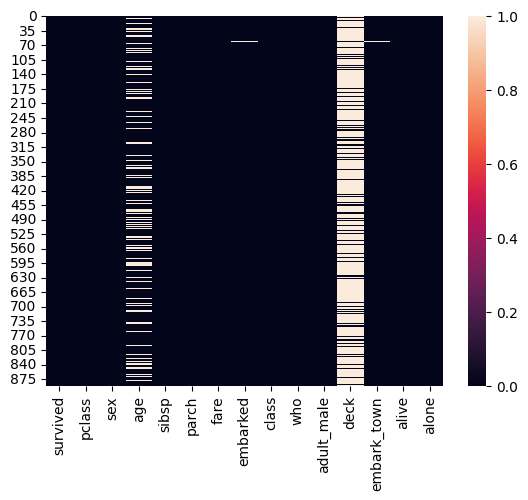

In [12]:
sns.heatmap(df.isnull()) #display a heatmap of missing values

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
df.shape

(891, 15)

In [15]:
df.dropna().shape # display the number of rows and columns after drop

(182, 15)

In [16]:
df.dropna(axis=1) #delete columns with missing values

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [17]:
df.dropna(axis=1).shape

(891, 11)

### Imputation Technique:
Imputation is the process of replacing missing data with substituted values.

* Mean Value Imputation: Handling missing values by replacing missing values with mean.

In [19]:
df['age'].isna().sum()

np.int64(177)

<Axes: xlabel='age', ylabel='Count'>

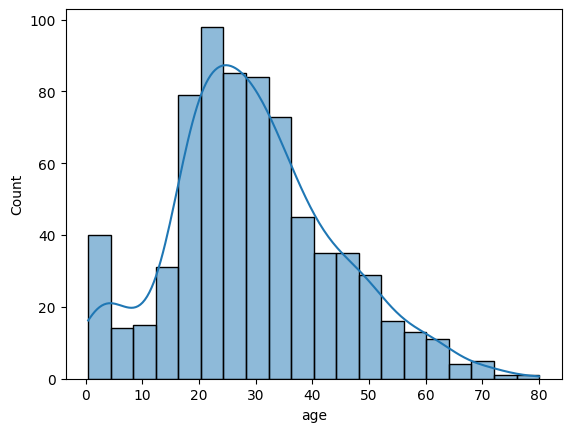

In [20]:
sns.histplot(df['age'], kde=True) #display histogram of age column

In [21]:
df.age

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [22]:
df['age'].mean() #display the mean of the 'age'

np.float64(29.69911764705882)

In [23]:
df['age_mean'] = df['age'].fillna(df['age'].mean()) #fill missing value

* Median Value Imputation: Handling missing values by replacing missing values with median. It is used normally when there are lots of outliers

In [24]:
df.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean
342,0,2,male,28.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,28.000000
739,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True,29.699118
137,0,1,male,37.0,1,0,53.1000,S,First,man,True,C,Southampton,no,False,37.000000


In [25]:
df['age_median']= df['age'].fillna(df['age'].median())

In [26]:
df[['age_median', 'age_mean', 'age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


* Mode value imputation: mainly used for categorical values

In [27]:
df.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
617,0,3,female,26.0,1,0,16.100,S,Third,woman,False,NaN,Southampton,no,False,26.000000,26.0
667,0,3,male,NaN,0,0,7.775,S,Third,man,True,NaN,Southampton,no,True,29.699118,28.0
508,0,3,male,28.0,0,0,22.525,S,Third,man,True,NaN,Southampton,no,True,28.000000,28.0


In [28]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [29]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [30]:
df['embarked'].head()

,embarked
0,S
1,C
2,S
3,S
4,S


In [31]:
import pandas as pd
pd.Categorical(df['embarked'])

['S', 'C', 'S', 'S', 'S', ..., 'S', 'S', 'S', 'C', 'Q']
Length: 891
Categories (3, object): ['C', 'Q', 'S']

In [32]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [34]:
df['embarked'].notna() #Not misssing

,embarked
0,True
1,True
2,True
3,True
4,True
...,...
886,True
887,True
888,True
889,True


In [38]:
mode = df[df['embarked'].notna()]['embarked'].mode()[0]

In [39]:
df['embarked_mode'] = df['embarked'].fillna(mode)

In [41]:
df[['embarked', 'embarked_mode']]

,embarked,embarked_mode
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [45]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median,embarked_mode
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0,S
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0,S


# Imbalanced dataset:
Data having more samples than others, causing models to favour majority
Ways to handle Imbalanced dataset:
* Upsampling: Increasing data counts in the columns with lower data samples.
* Downsampling: Decreasing data counts in the columns with higher samples.

In [47]:
import numpy as np

In [48]:
# Set the random seed for reproductivity
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples*class_0_ratio)
n_class_1 = n_samples - n_class_0

In [49]:
n_class_0, n_class_1

(900, 100)

In [50]:
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale = 1, size = n_class_0),
    'feature_2': np.random.normal(loc=0, scale = 1, size = n_class_0),
    'target': [0]*n_class_0
})
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size= n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size= n_class_1),
    'target': [1]*n_class_1
})

In [51]:
class_1

,feature_1,feature_2,target
0,1.699768,2.139033,1
1,1.367739,2.025577,1
2,1.795683,1.803557,1
3,2.213696,3.312255,1
4,3.033878,3.187417,1
...,...,...,...
95,1.376371,2.845701,1
96,2.239810,0.880077,1
97,1.131760,1.640703,1
98,2.902006,0.390305,1


In [52]:
 class_0

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
895,0.238761,-0.003155,0
896,-1.106386,-0.430660,0
897,0.366732,-0.146416,0
898,1.023906,1.160176,0


In [53]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [54]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [55]:
df.shape

(1000, 3)

In [56]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [57]:
df_minority = df[df['target'] == 0]
df_majority = df[df['target'] == 0]

In [58]:
df_minority.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [59]:
df_majority.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [60]:
df_majority.shape, df_minority.shape

((900, 3), (900, 3))

In [62]:
# Upsampling
from sklearn.utils import resample

In [64]:
df_minority_upsample = resample(df_minority, replace= True, #sample with replacement
                                n_samples = len(df_majority), #to match the majority class
                                random_state=42)

In [65]:
df_minority_upsample.shape

(900, 3)

In [66]:
df_minority_upsample['target'].value_counts()

,count
target,
0,900


In [67]:
df_upsampled = pd.concat([df_majority, df_minority_upsample])

In [68]:
df_upsampled.shape

(1800, 3)

In [69]:
# Downsampling
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale = 1, size = n_class_0),
    'feature_2': np.random.normal(loc=0, scale = 1, size = n_class_0),
    'target': [0]*n_class_0
})
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size= n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size= n_class_1),
    'target': [1]*n_class_1
})

In [79]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [80]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [81]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [82]:
df_majority_downsample = resample(df_majority, replace= False, #sample without replacement
                                n_samples = len(df_minority), #to match the minority class
                                random_state=42)

In [83]:
df_majority_downsample.shape

(100, 3)

In [84]:
df_downsample = pd.concat([df_minority, df_majority_downsample])

In [85]:
pd.concat([df_minority, df_majority_downsample]).value_counts()

,,,count
feature_1,feature_2,target,
-1.969990,0.130563,0,1
-1.932547,1.675827,0,1
-1.886397,0.855592,0,1
-1.861760,-0.033398,0,1
-1.584264,-0.756422,0,1
...,...,...,...
3.828316,2.125822,1,1
4.040317,3.145357,1,1
4.183720,1.713615,1,1


In [86]:
df_downsample['target'].value_counts()

,count
target,
1,100
0,100
